In [3]:
import os
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [2]:
from langchain_groq import ChatGroq
model=ChatGroq(model="openai/gpt-oss-120b")

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel

class State(TypedDict):
    topic:str
    joke:str
    improved_joke:str
    final_joke:str
    

In [4]:
def generate_joke(state:State):
    """First LLM call to generate initial joke"""
    
    msg=model.invoke(f"write a short joke about {state['topic']}")
    return {"joke":msg.content}

def check_punchline(state:State):
    """Gate function to check if the joke has a punchline"""
    
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Fail"
    return "Pass"

def improve_joke(state:State):
    """Second LLM call to improve the joke"""
    msg=model.invoke(f"Make this joke funnier by adding workplay: {state['joke']}")
    return {"improved_joke":msg.content}

def polish_joke(state:State):
    """Third LLM call for final polish"""
    
    msg=model.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke":msg.content}

    

In [5]:
workflow=StateGraph(State)

workflow.add_node("generate_joke",generate_joke)
workflow.add_node("improve_joke",improve_joke)
workflow.add_node("polish_joke",polish_joke)

workflow.add_edge(START,"generate_joke")
workflow.add_conditional_edges("generate_joke",check_punchline,{"Fail":"improve_joke","Pass":END})
workflow.add_edge("improve_joke","polish_joke")
workflow.add_edge("polish_joke",END)

chain=workflow.compile()




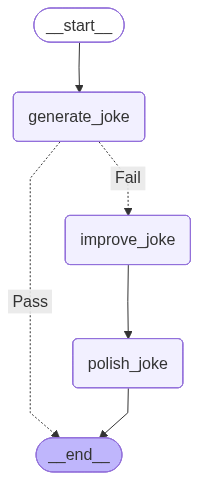

In [6]:
from IPython.display import Image,display
display(Image(chain.get_graph().draw_mermaid_png()))

In [7]:
state=chain.invoke({"topic":"cat"})
state

{'topic': 'cat',
 'joke': 'Why did the cat sit on the computer?  \n\nBecause it wanted to keep an eye on the mouse!',
 'improved_joke': '**Why did the cat sit on the computer?**  \n\nBecause it wanted to *purr*‑gram the mouse, keep an eye on the *cursor*‑ors, and make sure nobody *tabby*‑ed out of its\u202f*mouse‑tery* mission!',
 'final_joke': '**Why did the cat sit on the computer?**  \n\nBecause it wanted to *purr*‑gram the mouse, keep an eye on the *cursor*‑ors, and make sure nobody *tabby*‑ed out of its\u202f*mouse‑tery* mission!  \n\n*But the real surprise?* As soon as the screen flickered, the cat slipped on a tiny cape, typed a secret code, and—*purr‑haps more shocking than any pun*—downloaded the entire internet into a ball of yarn, declaring itself the **Fur‑mula One** of cyber‑espionage. 😺💾✨'}

### Parallelization

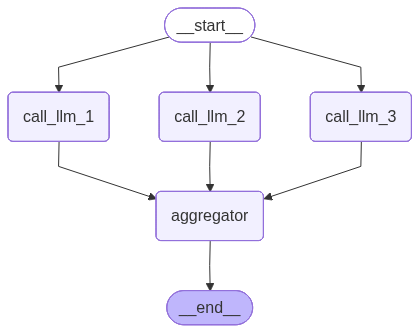

In [16]:
# Graph state

class State(TypedDict):
    topic:str
    joke:str
    story:str
    poem:str
    combined_output:str
    
    
#nodes

def call_llm_1(state:State):
    """"First LLM call to generate initial joke"""
    
    msg=model.invoke(f"Write a joke about {state['topic']}")
    return {"joke":msg.content}

def call_llm_2(state:State):
    """Second LLm call to generate story"""
    msg=model.invoke(f"Write a story about {state['topic']}")
    return {"story":msg.content}

def call_llm_3(state:State):
    """Thrid LLM call to generate poem"""
    msg=model.invoke(f"Write a poem about {state['topic']}")
    return {"poem":msg.content}

def aggregator(state:State):
    """combined the joke and story into a single output"""
    
    combined=f"Here a story , joke, and poem about {state['topic']}! \n\n"
    combined += f"Story:\n {state['story']}\n\n"
    combined += f"Joke: \n\ {state['joke']}\n\n"
    combined += f"Poem: \n {state['poem']}\n\n"
    return {"combined_output":combined}


parallel_builder=StateGraph(State)

parallel_builder.add_node("call_llm_1",call_llm_1)
parallel_builder.add_node("call_llm_2",call_llm_2)
parallel_builder.add_node("call_llm_3",call_llm_3)
parallel_builder.add_node("aggregator",aggregator)

parallel_builder.add_edge(START,"call_llm_1")
parallel_builder.add_edge(START,"call_llm_2")
parallel_builder.add_edge(START,"call_llm_3")
parallel_builder.add_edge("call_llm_1","aggregator")
parallel_builder.add_edge("call_llm_2","aggregator")
parallel_builder.add_edge("call_llm_3","aggregator")
parallel_builder.add_edge("aggregator",END)

parallel_workflow=parallel_builder.compile()

display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

    

In [17]:
state=parallel_workflow.invoke({'topic':"cats"})


In [ ]:
print(state["combined_output"])

Here a story , joke, and poem about cats! 

Story:
 **The Midnight Council of Whisker‑Wood**

When the last amber leaf fell from the great oak in the heart of Whisker‑Wood, the cats knew the season of the Long Night was about to begin. In the village of Purridge, every feline—from the sleek alley tabby to the regal long‑haired queen of the manor—gathered beneath the moonlit canopy for the first council of the year.

**The Invitation**

It began with a silver bell that rang only for those with whiskers. Old Tom, the village’s oldest tomcat, had found the bell tangled in a knot of ivy. He nudged it with his paw, and a soft, melodic chime echoed through the trees, rippling across rooftops and through the cracks of the stone walls. One by one, the cats felt the call in their bones and slipped from their warm laps, soft paws padding silently over cobblestones and garden fences.

**The Council Chamber**

At the base of the oak, a hollowed-out trunk served as the council chamber. Inside, the 

### Routing

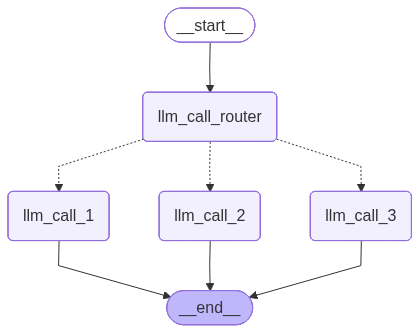

In [6]:
from typing import Literal,TypedDict
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage,SystemMessage
from IPython.display import Image,display

class Route(BaseModel):
    step:Literal['poem','story','joke']=Field(
        None,
        description="The next step in the routing process")
    

router=model.with_structured_output(Route)

class State(TypedDict):
    input:str
    decision:str
    output:str
    

def llm_call_1(state:State):
    """Write a story"""
    result=model.invoke(state['input'])
    return {"output":result.content}

def llm_call_2(state:State):
    """Write a joke"""
    print("LLM call 2 is called")
    
    result=model.invoke(state['input'])
    return {"output":result.content}

def llm_call_3(state:State):
    """Write a poem"""
    
    result=model.invoke(state['input'])
    return {"output":result.content}

def llm_call_router(state:State):
    """Route the input to the appropriate node"""
    
    decision=router.invoke([
        SystemMessage(content="Route the input to story, joke, or poem based on the user's request. "),
        HumanMessage(content=state['input']),
        
    ])
    return{"decision":decision.step}


def route_decision(state:State):
    if state['decision'] == "story":
        return "llm_call_1"
    elif state['decision'] == "joke":
        return "llm_call_2"
    elif state['decision'] == "poem":
        return "llm_call_3"
    
    

router_builder=StateGraph(State)

router_builder.add_node("llm_call_1",llm_call_1)
router_builder.add_node("llm_call_2",llm_call_2)
router_builder.add_node("llm_call_3",llm_call_3)
router_builder.add_node("llm_call_router",llm_call_router)

router_builder.add_edge(START,"llm_call_router")
router_builder.add_conditional_edges("llm_call_router",
                                     route_decision,
                                     {
                                         "llm_call_1":"llm_call_1",
                                         "llm_call_2":"llm_call_2",
                                         "llm_call_3":"llm_call_3",
                                     },

)
router_builder.add_edge("llm_call_1",END)
router_builder.add_edge("llm_call_2",END)
router_builder.add_edge("llm_call_3",END)


router_workflow=router_builder.compile()
display(Image(router_workflow.get_graph().draw_mermaid_png()))
    
    

In [8]:
state = router_workflow.invoke({"input": "Write me a poem about cats"})
print(state["output"])

**Whiskered Whispers**

In moonlit alleys, soft and sly,  
A shadow slips, a silver sigh—  
A feline grace, a velvet tread,  
Where night and mystery gently wed.

Emerald eyes, twin lanterns bright,  
Survey the world in amber light,  
Each twitching tail a metronome,  
Marking time in purrs and roam.

They dance on rooftops, sleek and fleet,  
With silent paws and heartbeats sweet,  
A whispered rustle, a soft caress,  
The world becomes a sun‑lit mess.

When sunrise paints the sky in gold,  
They curl in cushions, warm and bold,  
Dreams of hunting, feathered flight,  
Purring lullabies through the night.

Oh, cats—enigmatic, fierce, yet kind,  
A paradox of body, mind;  
They teach us stillness, curiosity,  
And how to love with mystery.


## Orchestrator-workers

In [9]:
from typing import Annotated,List
import operator

class Section(BaseModel):
    name:str=Field(description="Name for this section of the report.")
    description:str=Field(description="Brief overview of the main topics and concepts to be covered in this section.")
    
class Sections(BaseModel):
    sections:List[Section]=Field(description="Sections of the report.")
    
    
planner=model.with_structured_output(Sections)
    

In [ ]:
from langgraph.constants import Send


class State(TypedDict):
    topic:str
    sections:list[Section]
    completed_sections:Annotated[list,operator.add]
    final_report:str
    
    
class WorkerState(TypedDict):
    section:Section
    completed_sections:Annotated[list,operator.add]
    

def orchestrator(state:State):
    """orchestrator that generates a plan for the report"""
    
    report_sections=planner.invoke([
        SystemMessage(content="Generate a plan for the report."),
        HumanMessage(content=f"Here is the report topic:{state['topic']}")
    ])
    
    print("Report Sections:",report_sections)
    
    return {"sections":report_sections.sections}

def llm_call(state:WorkerState):
    """Worker writes a section of the report"""
    section=model.invoke([
        SystemMessage(content="Write a report section following the provided name and description. Include no preamble for each section.Use markdown formatting."),
        HumanMessage(content=f"Here is the section name:{state['section'].name} and description:{state['section'].description}")
    ])
    return {"completed_sections":[section.content]}

def synthesizer(state:State):
    """Synthesize full report from sections"""
    
    completed_sections=state["completed_sections"]
    completed_report_sections="\n\n---\n\n".join(completed_sections)
    
    return {"final_report": completed_report_sections}

def assign_worker(state:State):
    """Assign a worker to each section in the plan"""
    
    return[Send("llm_call",{"section":s}) for s in state['sections']]